# Spooky Author Identification — improvement A: log-linear pooling with joint calibration

The metric is log loss, and in every methodology the misclassified sentences carry about two thirds of it: the models are *confidently wrong* on a few sentences.
The three methodologies make partly different mistakes (all three fail on only 6.5% of sentences, at least one is right on 93.5%), so combining them should make
the wrong sentences less confidently wrong. Following Fredsgaard & Schmidt (2025), who show that ensembles gain from diverse members and that a **joint** calibration beats calibrating members separately, the
probabilities are pooled in the log domain with fitted exponents:
$$p_{\text{pool}}(c\mid x)=\frac{\prod_{m}p_m(c\mid x)^{\,w_m}}{\sum_{c'}\prod_{m}p_m(c'\mid x)^{\,w_m}},\qquad \mathbf w=\arg\min_{\mathbf w}\;-\frac1n\sum_i\log p_{\text{pool}}(y_i\mid x_i).$$
A common scale on all exponents is a temperature on the pool, so the exponents are the joint calibration; unlike a mixture they can *sharpen* the member that is right and *flatten* the others.
Only three numbers are fitted. **Every exponent used to score a fold is fitted on the other four folds' out-of-fold predictions** (`spooky_pool.nested_pool`; the unit tests include a leakage test and a mutant that fits on all rows).
This is not a fourth methodology: it combines the three already trained, with no new training.

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix
import spooky_common as S, spooky_pool as PL
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
AU = S.AUTHORS; K = ["nblr", "style_gbdt", "cnn"]; NAME = {"nblr": "1. NB-weighted n-gram LR", "style_gbdt": "2. Stylometry + topics", "cnn": "3. Char + word CNN"}; COL = {"nblr": "#4C72B0", "style_gbdt": "#55A868", "cnn": "#C44E52", "pool": "#8172B2"}
os.makedirs("assets", exist_ok=True); os.makedirs("submissions", exist_ok=True)
train, test, folds, y = S.load(); P = {k: S.load_method(k)[0] for k in K}; PT = {k: S.load_method(k)[1] for k in K}
VAR = {"pool of all three": K, "pool without stylometry": ["nblr", "cnn"], "pool without CNN": ["nblr", "style_gbdt"]}
OOF, W, E = {}, {}, {}
for name, members in VAR.items():
    OOF[name], W[name] = PL.nested_pool([P[m] for m in members], y, folds); E[name] = S.evaluate(y, OOF[name], folds)
for k in K: E[NAME[k]] = S.evaluate(y, P[k], folds)
rows = {n: dict(log_loss=e["log_loss"], ci_low=e["log_loss_ci95"][0], ci_high=e["log_loss_ci95"][1], accuracy=e["accuracy"], macro_f1=e["macro_f1"], fold_sd=np.std(e["fold_log_loss"])) for n, e in E.items()}
tab = pd.DataFrame(rows).T.loc[[NAME[k] for k in K] + list(VAR)]; display(tab.round(4))
best = "pool of all three"; e = E[best]
print(f"FINAL pool of all three methodologies: log loss {e['log_loss']:.4f} {np.round(e['log_loss_ci95'], 4)}  accuracy {e['accuracy']:.4f}  macro-F1 {e['macro_f1']:.4f}  per-author F1 { {a: round(v, 3) for a, v in e['f1_per_author'].items()} }")
print("per-fold log loss:", np.round(e["fold_log_loss"], 4), "| single nblr per fold:", np.round(E[NAME['nblr']]["fold_log_loss"], 4))
for n in [NAME[k] for k in K] + ["pool without stylometry", "pool without CNN"]:
    d, ci, share = S.paired_bootstrap_logloss(y, OOF[best], OOF[n] if n in OOF else P[[k for k in K if NAME[k] == n][0]], n=3000); print(f"paired difference, pool of all three minus {n}: {d:+.4f} 95% interval [{ci[0]:+.4f}, {ci[1]:+.4f}]")
print("exponents per fold (nblr, style, cnn):", [np.round(w, 3).tolist() for w in W[best]]); print("mean exponents:", np.round(W[best].mean(0), 3).tolist(), "| sum", round(float(W[best].mean(0).sum()), 3), "(sum > 1: the pool is sharper than a plain geometric mean)")

,log_loss,ci_low,ci_high,accuracy,macro_f1,fold_sd
1. NB-weighted n-gram LR,0.3441,0.3343,0.3547,0.8719,0.8719,0.0087
2. Stylometry + topics,0.6276,0.6170,0.6375,0.7355,0.7331,0.0115
3. Char + word CNN,0.4822,0.4720,0.4924,0.8066,0.8064,0.0068
pool of all three,0.3373,0.3272,0.3478,0.8719,0.8718,0.0099
pool without stylometry,0.3395,0.3297,0.3499,0.8712,0.8712,0.0099
pool without CNN,0.3403,0.3298,0.3506,0.8725,0.8724,0.0096


FINAL pool of all three methodologies: log loss 0.3373 [0.3272 0.3478]  accuracy 0.8719  macro-F1 0.8718  per-author F1 {'EAP': 0.874, 'HPL': 0.877, 'MWS': 0.865}
per-fold log loss: [0.3547 0.3292 0.3343 0.3274 0.3411] | single nblr per fold: [0.359  0.3369 0.342  0.3348 0.348 ]


paired difference, pool of all three minus 1. NB-weighted n-gram LR: -0.0068 95% interval [-0.0085, -0.0051]


paired difference, pool of all three minus 2. Stylometry + topics: -0.2902 95% interval [-0.2997, -0.2808]


paired difference, pool of all three minus 3. Char + word CNN: -0.1449 95% interval [-0.1523, -0.1375]


paired difference, pool of all three minus pool without stylometry: -0.0022 95% interval [-0.0031, -0.0013]


paired difference, pool of all three minus pool without CNN: -0.0029 95% interval [-0.0040, -0.0018]
exponents per fold (nblr, style, cnn): [[0.83, 0.144, 0.193], [0.818, 0.151, 0.161], [0.82, 0.149, 0.162], [0.812, 0.128, 0.179], [0.823, 0.157, 0.166]]
mean exponents: [0.821, 0.146, 0.172] | sum 1.139 (sum > 1: the pool is sharper than a plain geometric mean)


## 1. Final metrics and what each member contributes

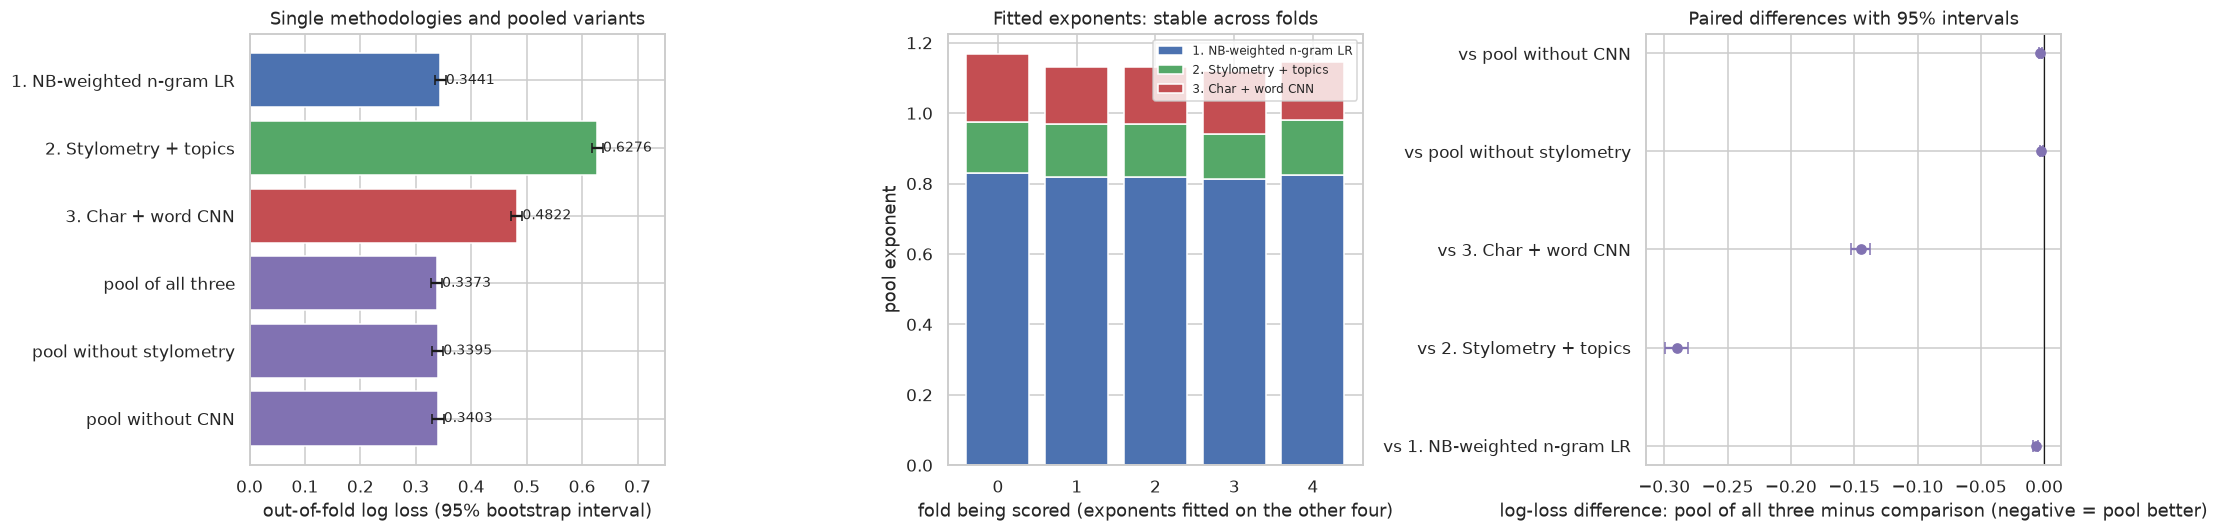

,exponent_mean,exponent_sd
1. NB-weighted n-gram LR,0.821,0.006
2. Stylometry + topics,0.146,0.010
3. Char + word CNN,0.172,0.012


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
names = list(tab.index); cols = [COL[k] for k in K] + [COL["pool"]] * 3; vals = tab.log_loss.values
axes[0].barh(names[::-1], vals[::-1], xerr=[(tab.log_loss - tab.ci_low).values[::-1], (tab.ci_high - tab.log_loss).values[::-1]], color=cols[::-1], capsize=3)
for i, v in enumerate(vals[::-1]): axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=9)
axes[0].set_xlim(0, 0.75); axes[0].set_xlabel("out-of-fold log loss (95% bootstrap interval)"); axes[0].set_title("Single methodologies and pooled variants")
w = W[best]; bottom = np.zeros(5)
for j, k in enumerate(K): axes[1].bar(range(5), w[:, j], bottom=bottom, color=COL[k], label=NAME[k]); bottom += w[:, j]
axes[1].set_xlabel("fold being scored (exponents fitted on the other four)"); axes[1].set_ylabel("pool exponent"); axes[1].set_title("Fitted exponents: stable across folds"); axes[1].legend(fontsize=8)
diffs = []
for n in names[:3]:
    d, ci, _ = S.paired_bootstrap_logloss(y, OOF[best], P[K[names.index(n)]], n=2000); diffs.append((n, d, ci))
for n in ["pool without stylometry", "pool without CNN"]:
    d, ci, _ = S.paired_bootstrap_logloss(y, OOF[best], OOF[n], n=2000); diffs.append((n, d, ci))
axes[2].errorbar([d for _, d, _ in diffs], range(len(diffs)), xerr=[[d - ci[0] for _, d, ci in diffs], [ci[1] - d for _, d, ci in diffs]], fmt="o", color=COL["pool"], capsize=4)
axes[2].set_yticks(range(len(diffs)), [f"vs {n}" for n, _, _ in diffs]); axes[2].axvline(0, color="k", lw=.8); axes[2].set_xlabel("log-loss difference: pool of all three minus comparison (negative = pool better)"); axes[2].set_title("Paired differences with 95% intervals")
plt.tight_layout(); plt.savefig("assets/pool_01_final_metrics.png", bbox_inches="tight"); plt.show()
display(pd.DataFrame({"exponent_mean": W[best].mean(0), "exponent_sd": W[best].std(0)}, index=[NAME[k] for k in K]).round(3))

## 2. Does pooling do what it was meant to do: make wrong sentences less confidently wrong?

,nblr (best single),pool of all three
mean_loss,0.3441,0.3373
errors_pct,0.1281,0.1281
errors_share_of_loss,0.6715,0.6785
worst5_share,0.4176,0.4193
loss_on_correct,0.1296,0.1244
loss_on_wrong,1.8041,1.7861
confidence_on_errors,0.6818,0.6807
confident_errors_gt_0_9,286.0000,272.0000


                         nblr (best single)  pool of all three
mean_loss                            0.3441             0.3373
errors_pct                           0.1281             0.1281
errors_share_of_loss                 0.6715             0.6785
worst5_share                         0.4176             0.4193
loss_on_correct                      0.1296             0.1244
loss_on_wrong                        1.8041             1.7861
confidence_on_errors                 0.6818             0.6807
confident_errors_gt_0_9            286.0000           272.0000


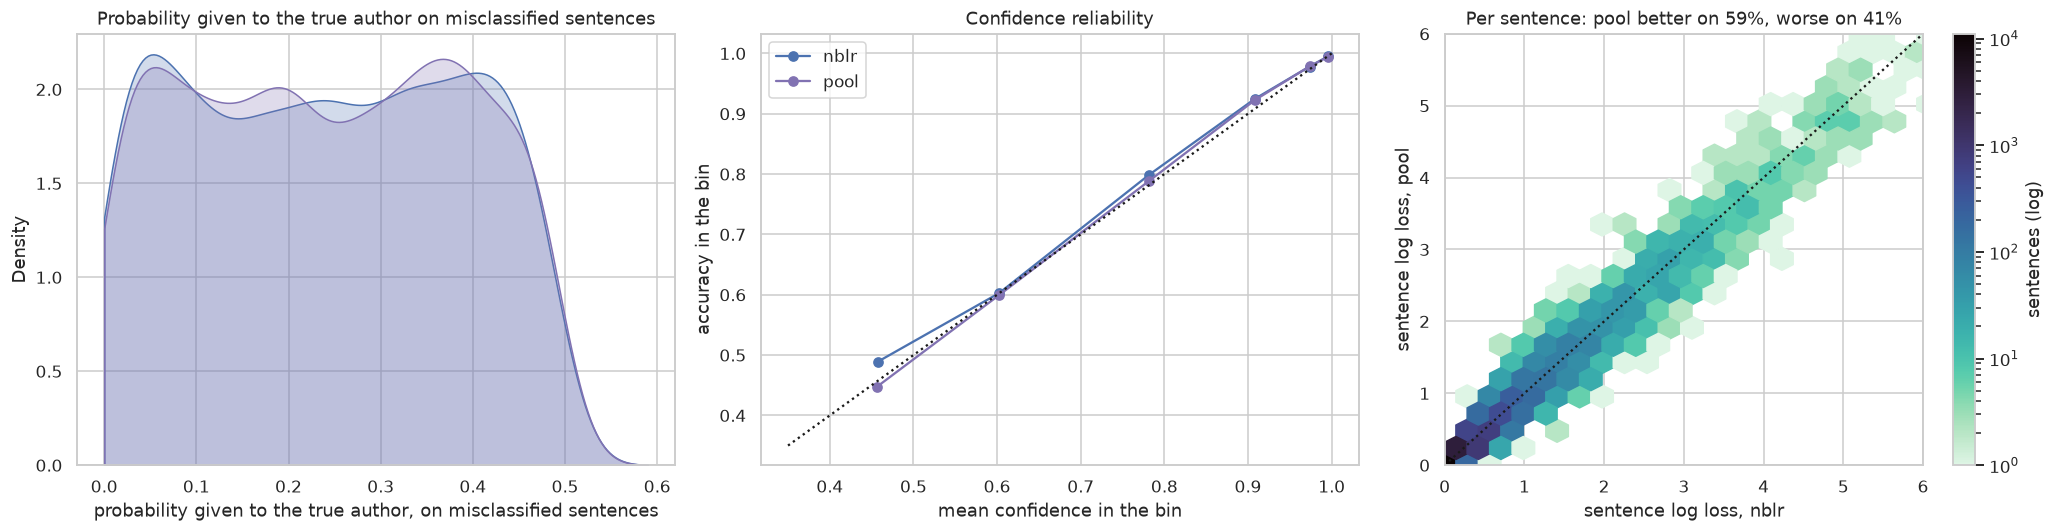

sentences improved 11532, worsened 8047; total loss removed 133.3 nats of 6738.0; gain concentrated in the sentences nblr got wrong: 74% of the net gain


In [3]:
def decomp(p):
    nll = S.sample_loss(y, p); wrong = p.argmax(1) != y; order = np.sort(nll)[::-1]
    return dict(mean_loss=nll.mean(), errors_pct=wrong.mean(), errors_share_of_loss=nll[wrong].sum() / nll.sum(), worst5_share=order[:int(.05 * len(y))].sum() / nll.sum(), loss_on_correct=nll[~wrong].mean(), loss_on_wrong=nll[wrong].mean(), confidence_on_errors=p.max(1)[wrong].mean(), confident_errors_gt_0_9=int((wrong & (p.max(1) > 0.9)).sum()))
dec = pd.DataFrame({"nblr (best single)": decomp(P["nblr"]), "pool of all three": decomp(OOF[best])}); display(dec.round(4)); print(dec.round(4).to_string())
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
wr_n, wr_p = P["nblr"].argmax(1) != y, OOF[best].argmax(1) != y
for p, wr, lab, c in [(P["nblr"], wr_n, "nblr", COL["nblr"]), (OOF[best], wr_p, "pool", COL["pool"])]: sns.kdeplot(p[np.arange(len(y)), y][wr], ax=axes[0], label=f"{lab} ({wr.sum()} errors)", color=c, fill=True, alpha=.25, clip=(0, 1))
axes[0].set_xlabel("probability given to the true author, on misclassified sentences"); axes[0].set_title("Probability given to the true author on misclassified sentences")
for p, lab, c in [(P["nblr"], "nblr", COL["nblr"]), (OOF[best], "pool", COL["pool"])]:
    conf, ok = p.max(1), p.argmax(1) == y; bins = pd.cut(conf, [0.33, 0.5, 0.7, 0.85, 0.95, 0.99, 1.0]); g = pd.DataFrame({"b": bins, "ok": ok, "c": conf}).groupby("b", observed=True).agg(acc=("ok", "mean"), conf=("c", "mean"))
    axes[1].plot(g.conf, g.acc, "o-", color=c, label=lab)
axes[1].plot([0.35, 1], [0.35, 1], "k:"); axes[1].set_xlabel("mean confidence in the bin"); axes[1].set_ylabel("accuracy in the bin"); axes[1].legend(); axes[1].set_title("Confidence reliability")
nl, pl_ = S.sample_loss(y, P["nblr"]), S.sample_loss(y, OOF[best]); gain = nl - pl_
hb = axes[2].hexbin(nl, pl_, gridsize=40, bins="log", cmap="mako_r", mincnt=1); axes[2].plot([0, 6], [0, 6], "k:"); axes[2].set_xlim(0, 6); axes[2].set_ylim(0, 6)
axes[2].set_xlabel("sentence log loss, nblr"); axes[2].set_ylabel("sentence log loss, pool"); axes[2].set_title(f"Per sentence: pool better on {(gain > 0).mean():.0%}, worse on {(gain < 0).mean():.0%}"); plt.colorbar(hb, ax=axes[2], label="sentences (log)")
plt.tight_layout(); plt.savefig("assets/pool_02_error_behaviour.png", bbox_inches="tight"); plt.show()
print(f"sentences improved {int((gain > 1e-9).sum())}, worsened {int((gain < -1e-9).sum())}; total loss removed {gain.sum():.1f} nats of {nl.sum():.1f}; gain concentrated in the sentences nblr got wrong: {gain[wr_n].sum() / gain.sum():.0%} of the net gain")

## 3. Where the gain lands

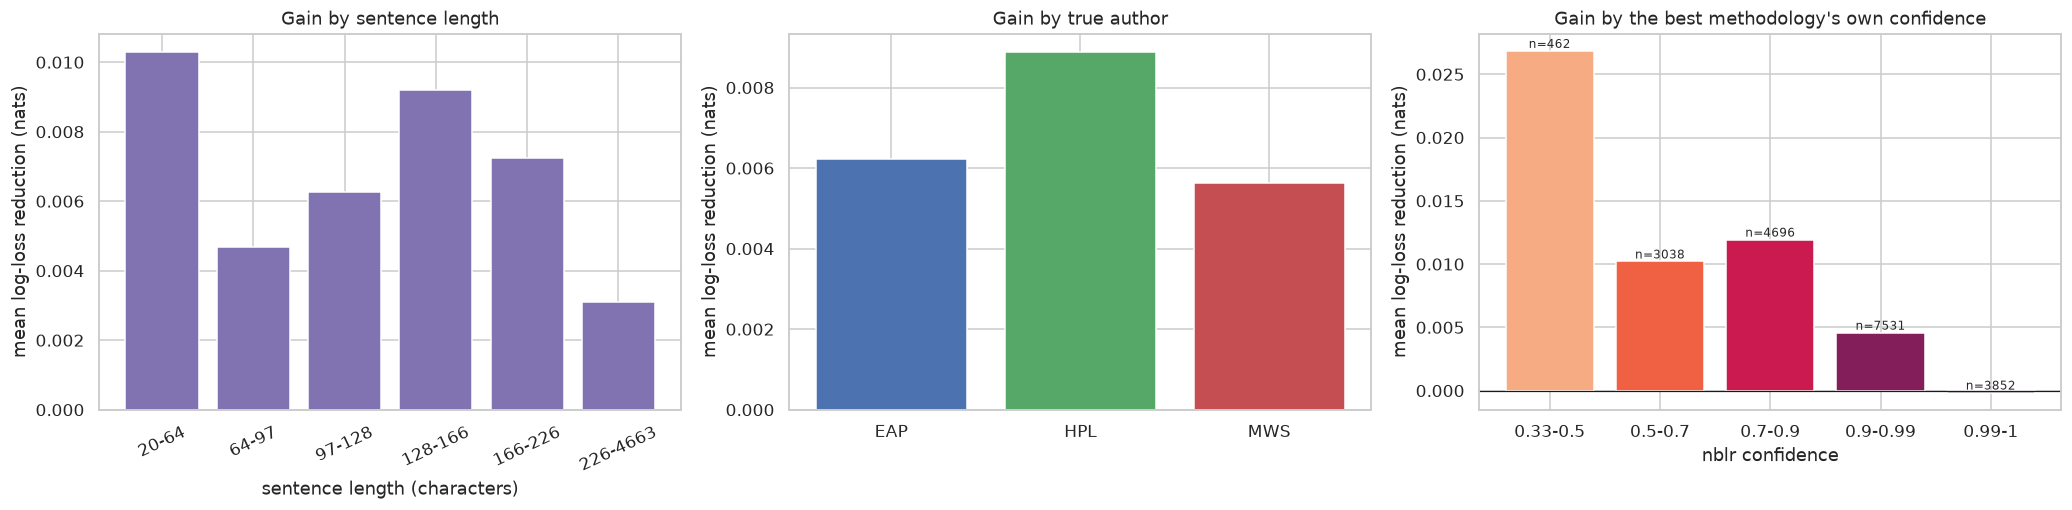

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
L = train.text.str.len(); b = pd.qcut(L, 6); g = pd.DataFrame({"b": b, "gain": gain}).groupby("b", observed=True).gain.mean(); axes[0].bar(range(6), g.values, color=COL["pool"]); axes[0].set_xticks(range(6), [f"{int(i.left)}-{int(i.right)}" for i in g.index], rotation=25)
axes[0].set_xlabel("sentence length (characters)"); axes[0].set_ylabel("mean log-loss reduction (nats)"); axes[0].set_title("Gain by sentence length")
ga = pd.DataFrame({"a": train.author.values, "gain": gain}).groupby("a").gain.mean().loc[AU]; axes[1].bar(AU, ga.values, color=[COL["nblr"], COL["style_gbdt"], COL["cnn"]]); axes[1].set_ylabel("mean log-loss reduction (nats)"); axes[1].set_title("Gain by true author")
cb = pd.cut(P["nblr"].max(1), [0.33, 0.5, 0.7, 0.9, 0.99, 1.0]); gc = pd.DataFrame({"b": cb, "gain": gain}).groupby("b", observed=True).gain.agg(["mean", "size"]); axes[2].bar(range(len(gc)), gc["mean"], color=sns.color_palette("rocket_r", len(gc)))
axes[2].set_xticks(range(len(gc)), [f"{i.left:g}-{i.right:g}" for i in gc.index]); axes[2].axhline(0, color="k", lw=.8); axes[2].set_xlabel("nblr confidence"); axes[2].set_ylabel("mean log-loss reduction (nats)"); axes[2].set_title("Gain by the best methodology's own confidence")
for i, n_ in enumerate(gc["size"]): axes[2].text(i, gc["mean"].iloc[i], f"n={n_}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig("assets/pool_03_where_gain_lands.png", bbox_inches="tight"); plt.show()

## 4. Test predictions and saved results

For the test sentences, the exponents are fitted on **all** out-of-fold predictions and applied to the three methodologies' fold-averaged test probabilities.

In [5]:
w_all = PL.fit_exponents([P[k] for k in K], y); pt = PL.pool([PT[k] for k in K], w_all); oof_pool = OOF[best]
print("exponents fitted on all out-of-fold rows (nblr, style, cnn):", np.round(w_all, 3).tolist(), "| in-sample log loss", round(float(S.sample_loss(y, PL.pool([P[k] for k in K], w_all)).mean()), 4))
sub = pd.DataFrame(S.clip_norm(pt), columns=AU); sub.insert(0, "id", test.id.values); sample = pd.read_csv("data/sample_submission.csv"); assert (sample.id.values == sub.id.values).all() and list(sample.columns[1:]) == AU
sub.to_csv("submissions/submission_pool_geo.csv", index=False); print("submission_pool_geo.csv", sub.shape, "| predicted class shares on test:", sub[AU].mean().round(3).to_dict(), "| out-of-fold predicted shares:", pd.Series(oof_pool.argmax(1)).map(dict(enumerate(AU))).value_counts(normalize=True).loc[AU].round(3).to_dict())
S.save_method("pool_geo", oof_pool, pt, dict(method="log-linear pool of the three methodologies with jointly fitted exponents", members=K, exponents_all_rows=w_all.tolist(), exponents_per_fold=W[best].tolist(), **e))
json.dump(dict(pool_all=dict(log_loss=e["log_loss"], ci95=e["log_loss_ci95"], accuracy=e["accuracy"], macro_f1=e["macro_f1"], fold_log_loss=e["fold_log_loss"]), variants={n: dict(log_loss=E[n]["log_loss"], accuracy=E[n]["accuracy"]) for n in E},
           decomposition=dec.to_dict()), open("results/pool_summary.json", "w"), indent=2, default=float)

exponents fitted on all out-of-fold rows (nblr, style, cnn): [0.821, 0.146, 0.171] | in-sample log loss 0.3369
submission_pool_geo.csv (8392, 4) | predicted class shares on test: {'EAP': 0.416, 'HPL': 0.276, 'MWS': 0.308} | out-of-fold predicted shares: {'EAP': 0.429, 'HPL': 0.273, 'MWS': 0.298}
